In [12]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
color=sns.color_palette()

In [3]:
df=pd.read_csv('student_performance.csv')
df.head()

,Student_ID,Study_Hours,Attendance,Previous_Marks,Assignments,Internal_Marks,Final_Result
0,1,6,79,75,43,78,Pass
1,2,3,84,43,100,73,Pass
2,3,4,71,46,81,43,Pass
3,4,6,68,68,66,32,Pass
4,5,2,90,38,58,91,Pass


In [4]:
df.tail()

,Student_ID,Study_Hours,Attendance,Previous_Marks,Assignments,Internal_Marks,Final_Result
1995,1996,3,60,57,35,74,Pass
1996,1997,4,74,76,71,37,Pass
1997,1998,4,96,59,58,47,Pass
1998,1999,0,92,52,33,62,Pass
1999,2000,1,92,45,86,30,Fail


In [5]:
student_id=df[df.Student_ID=='1999']
student_id.head()

,Student_ID,Study_Hours,Attendance,Previous_Marks,Assignments,Internal_Marks,Final_Result


In [6]:
df.shape

(2000, 7)

In [7]:
df.describe

,Student_ID,Study_Hours,Attendance,Previous_Marks,Assignments,Internal_Marks
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2.967000,69.734500,65.626500,65.464500,65.063500
std,577.494589,2.014433,17.523628,20.203022,20.483396,20.483365
min,1.000000,0.000000,40.000000,30.000000,30.000000,30.000000
25%,500.750000,1.000000,55.000000,48.000000,48.000000,48.000000
50%,1000.500000,3.000000,69.500000,66.000000,66.000000,64.000000
75%,1500.250000,5.000000,85.000000,83.000000,83.000000,83.000000
max,2000.000000,6.000000,100.000000,100.000000,100.000000,100.000000


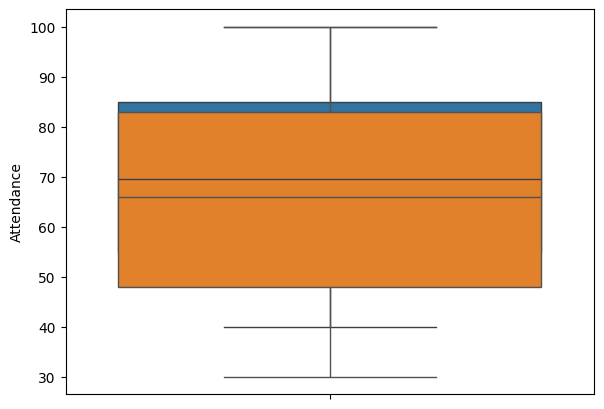

In [21]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(y=df['Attendance'])
plt.subplot(1,2,1)
sns.boxplot(y=df['Previous_Marks'])
plt.show()

In [22]:
df["Previous_Marks"].value_counts()

Previous_Marks
88    46
42    42
57    41
46    40
76    38
      ..
81    19
31    19
60    19
36    18
99    16
Name: count, Length: 71, dtype: int64

In [23]:
df["Previous_Marks"].value_counts(normalize=True)

Previous_Marks
88    0.0230
42    0.0210
57    0.0205
46    0.0200
76    0.0190
       ...  
81    0.0095
31    0.0095
60    0.0095
36    0.0090
99    0.0080
Name: proportion, Length: 71, dtype: float64

In [24]:
df["Previous_Marks"].value_counts(normalize=False)

Previous_Marks
88    46
42    42
57    41
46    40
76    38
      ..
81    19
31    19
60    19
36    18
99    16
Name: count, Length: 71, dtype: int64

In [25]:
df["Study_Hours"].value_counts()

Study_Hours
0    307
4    295
1    282
6    281
5    280
2    279
3    276
Name: count, dtype: int64

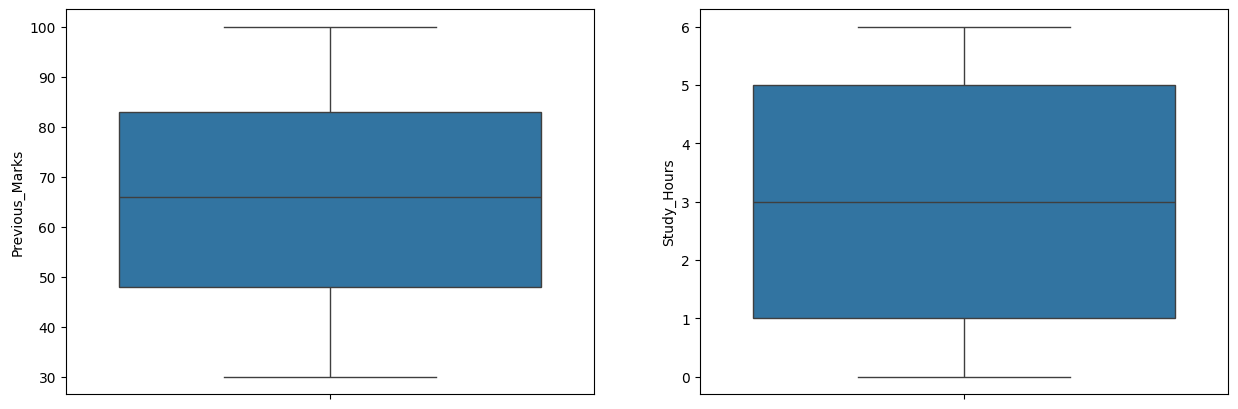

In [50]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(df['Previous_Marks'])
plt.subplot(1,2,2)
sns.boxplot(df['Study_Hours'])
plt.show()


In [51]:
df.isnull().sum()

Student_ID        0
Study_Hours       0
Attendance        0
Previous_Marks    0
Assignments       0
Internal_Marks    0
Final_Result      0
dtype: int64

In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# Define features (X) and target (y)
X = df[['Student_ID','Study_Hours','Attendance','Previous_Marks','Assignments','Internal_Marks']]
y = df['Final_Result']   # or 'Final_Result' depending on your dataset column name

# Initialize scaler
scaler = StandardScaler()

# Fit and transform features
X_scaled = scaler.fit_transform(X)

# Now use X_scaled instead of X when splitting
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
from sklearn.tree import DecisionTreeClassifier
dct=DecisionTreeClassifier()
dct.fit(X_train,y_train)
y_pred=dct.predict(X_test)
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))


[[ 40  10]
 [  5 345]]


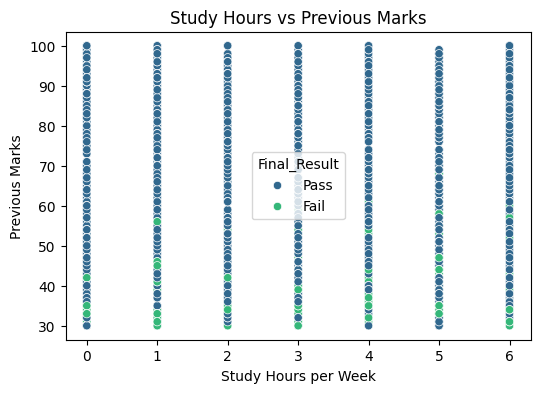

C:\Users\USER\AppData\Local\Temp\ipykernel_11188\671909311.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Final_Result'], y=df['Attendance'], palette="Set2")


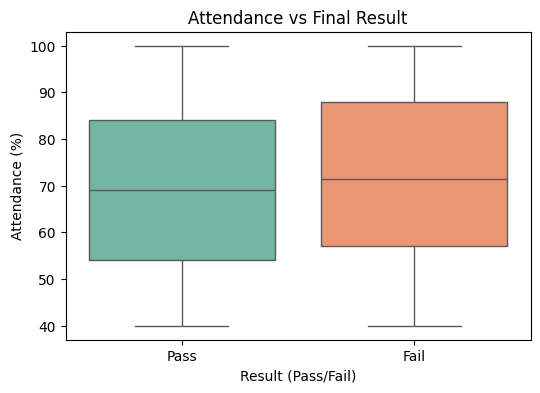

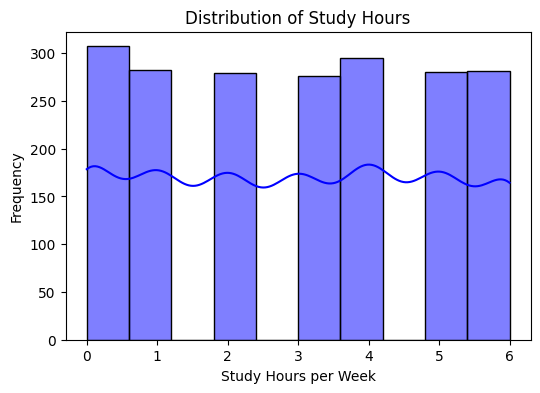

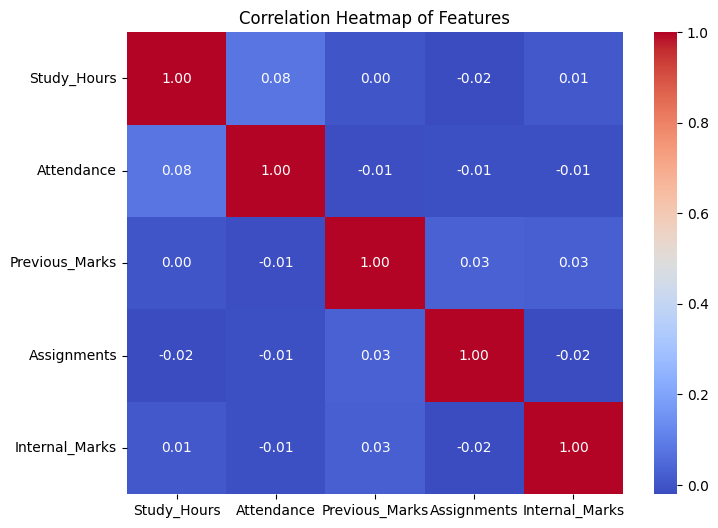

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Study Hours vs Marks
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Study_Hours'], y=df['Previous_Marks'], hue=df['Final_Result'], palette="viridis")
plt.title("Study Hours vs Previous Marks")
plt.xlabel("Study Hours per Week")
plt.ylabel("Previous Marks")
plt.show()

# 2. Attendance vs Result
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Final_Result'], y=df['Attendance'], palette="Set2")
plt.title("Attendance vs Final Result")
plt.xlabel("Result (Pass/Fail)")
plt.ylabel("Attendance (%)")
plt.show()

# 3. Distribution of Study Hours
plt.figure(figsize=(6,4))
sns.histplot(df['Study_Hours'], bins=10, kde=True, color="blue")
plt.title("Distribution of Study Hours")
plt.xlabel("Study Hours per Week")
plt.ylabel("Frequency")
plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['Study_Hours','Attendance','Previous_Marks','Assignments','Internal_Marks']].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Features")
plt.show()


In [56]:
# Step 4: Feature Selection
# Selecting important features: Study Hours, Attendance, Previous Marks

# Define selected features (X) and target (y)
X = df[['Study_Hours','Attendance','Previous_Marks']]
y = df['Final_Result']   # or 'Final_Result' depending on your dataset

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model (example: RandomForest)
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.87
Confusion Matrix:
 [[ 14  36]
 [ 16 334]]
Classification Report:
               precision    recall  f1-score   support

        Fail       0.47      0.28      0.35        50
        Pass       0.90      0.95      0.93       350

    accuracy                           0.87       400
   macro avg       0.68      0.62      0.64       400
weighted avg       0.85      0.87      0.86       400



In [57]:
# Step 5: Model Selection
# Apply Logistic Regression, Decision Tree, Naive Bayes, and SVM

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Features and target (from Step 4 feature selection)
X = df[['Study_Hours','Attendance','Previous_Marks']]
y = df['Final_Result']   # or 'Final_Result'

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC()
}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))



Logistic Regression
Accuracy: 0.8725
Confusion Matrix:
 [[  8  42]
 [  9 341]]
Classification Report:
               precision    recall  f1-score   support

        Fail       0.47      0.16      0.24        50
        Pass       0.89      0.97      0.93       350

    accuracy                           0.87       400
   macro avg       0.68      0.57      0.58       400
weighted avg       0.84      0.87      0.84       400


Decision Tree
Accuracy: 0.855
Confusion Matrix:
 [[ 17  33]
 [ 25 325]]
Classification Report:
               precision    recall  f1-score   support

        Fail       0.40      0.34      0.37        50
        Pass       0.91      0.93      0.92       350

    accuracy                           0.85       400
   macro avg       0.66      0.63      0.64       400
weighted avg       0.84      0.85      0.85       400


Naive Bayes
Accuracy: 0.8775
Confusion Matrix:
 [[  5  45]
 [  4 346]]
Classification Report:
               precision    recall  f1-score   sup

C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [58]:
# Step 6: Model Training
# Split dataset: Training (80%) and Testing (20%)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Features and target (from Step 4 feature selection)
X = df[['Study_Hours','Attendance','Previous_Marks']]
y = df['Final_Result']   # or 'Final_Result'

# Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC()
}

# Train models using training data
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully.")


Logistic Regression trained successfully.
Decision Tree trained successfully.
Naive Bayes trained successfully.
Support Vector Machine trained successfully.


In [59]:
# Step 7: Prediction - Pass/Fail

# Example new student data
new_student = [[6, 85, 72]]   # [Study_Hours, Attendance, Previous_marks]

# Predict using Logistic Regression (or any trained model)
prediction = trained_models["Logistic Regression"].predict(new_student)
print("Predicted Result (Pass/Fail):", prediction[0])


Predicted Result (Pass/Fail): Pass


C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [60]:
# Step 7: Prediction - Grades (A, B, C)

# Example new student data
new_student = [[8, 90, 85]]   # [Study_Hours, Attendance, Previous_marks]

# Predict using Decision Tree (or any trained model)
grade_prediction = trained_models["Decision Tree"].predict(new_student)
print("Predicted Grade:", grade_prediction[0])


Predicted Grade: Pass


C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Evaluate each trained model
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    
    print(f"\n{name} Evaluation")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='binary', pos_label="Pass"))
    print("Recall:", recall_score(y_test, y_pred, average='binary', pos_label="Pass"))
    print("F1-Score:", f1_score(y_test, y_pred, average='binary', pos_label="Pass"))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=["Pass","Fail"])
    print("Confusion Matrix:\n", cm)



Logistic Regression Evaluation
Accuracy: 0.8725
Precision: 0.8903394255874674
Recall: 0.9742857142857143
F1-Score: 0.9304229195088677
Confusion Matrix:
 [[341   9]
 [ 42   8]]

Decision Tree Evaluation
Accuracy: 0.8575
Precision: 0.9080779944289693
Recall: 0.9314285714285714
F1-Score: 0.919605077574048
Confusion Matrix:
 [[326  24]
 [ 33  17]]

Naive Bayes Evaluation
Accuracy: 0.8775
Precision: 0.8849104859335039
Recall: 0.9885714285714285
F1-Score: 0.9338731443994602
Confusion Matrix:
 [[346   4]
 [ 45   5]]

Support Vector Machine Evaluation
Accuracy: 0.875
Precision: 0.875
Recall: 1.0
F1-Score: 0.9333333333333333
Confusion Matrix:
 [[350   0]
 [ 50   0]]


C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Predicted Result: Pass


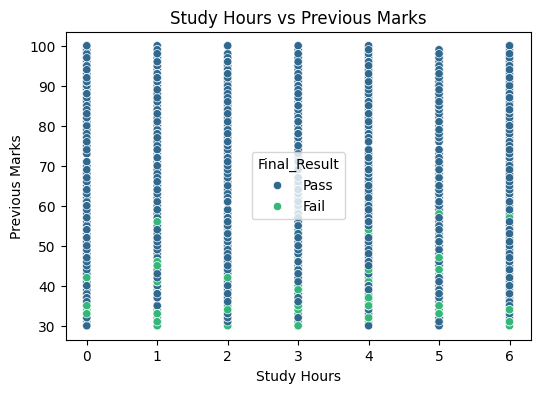

C:\Users\USER\AppData\Local\Temp\ipykernel_11188\3006572107.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Final_Result'], y=df['Attendance'], palette="Set2")


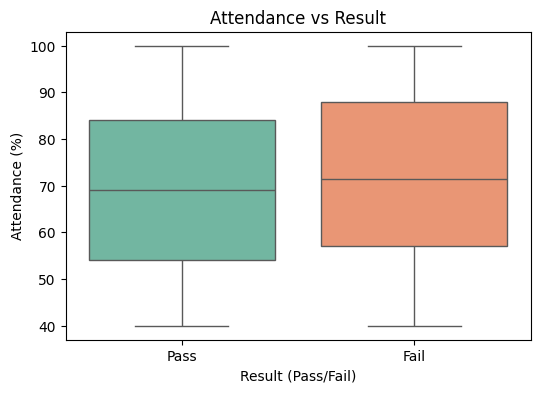


List of At-Risk Students:
      Student_ID  Study_Hours  Attendance  Previous_Marks  Assignments  \
3              4            6          68              68           66   
6              7            4          42              52           44   
11            12            2          66              91           50   
12            13            2          52              64           93   
14            15            3          72              59           56   
...          ...          ...         ...             ...          ...   
1991        1992            5          64              65           86   
1992        1993            4          86              37           58   
1994        1995            4          54              65           44   
1995        1996            3          60              57           35   
1999        2000            1          92              45           86   

     Final_Result  
3            Pass  
6            Pass  
11           Pass  
12  

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# 1. Student Performance Prediction
new_student = [[6, 85, 72]]   # Example input: [Study_Hours, Attendance, Previous_marks]
prediction = trained_models["Logistic Regression"].predict(new_student)
print("Predicted Result:", prediction[0])   # Pass/Fail or Grade

# 2. Graphs Showing Trends
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Study_Hours'], y=df['Previous_Marks'], hue=df['Final_Result'], palette="viridis")
plt.title("Study Hours vs Previous Marks")
plt.xlabel("Study Hours")
plt.ylabel("Previous Marks")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Final_Result'], y=df['Attendance'], palette="Set2")
plt.title("Attendance vs Result")
plt.xlabel("Result (Pass/Fail)")
plt.ylabel("Attendance (%)")
plt.show()

# 3. List of At-Risk Students (low attendance or failing prediction)
at_risk = df[(df['Attendance'] < 70) | (df['Final_Result'] == "Fail")]
print("\nList of At-Risk Students:")
print(at_risk[['Student_ID','Study_Hours','Attendance','Previous_Marks','Assignments','Final_Result']])


